# Gold mining in the Amazon: starter

Data for Good, Sessions 3 to 5. Run this once, top to bottom, before you do anything else.

It does four things:

1. loads the six shared tables and reproduces the numbers the publishers show (if a
   check fails, stop and find out why before you go on);
2. shows the difference between a **level** (hectares classified as mining in a year)
   and an **addition** (the change from the year before);
3. builds a **before/after table with a comparison group**;
4. draws **one figure** in a plain style.

Needs only `pandas` and `matplotlib`. Run it from the `starter` folder. Use any software
you like for your own work; `gold_starter.R` does the same steps in R.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

DATA = Path("../data") if Path("../data").exists() else Path("data")

prices_m = pd.read_csv(DATA / "prices_monthly.csv")           # world prices, one row per month
prices   = pd.read_csv(DATA / "prices_annual.csv")            # world prices, one row per year
substance = pd.read_csv(DATA / "mining_area.csv")             # Brazil: mining by type and substance
br = pd.read_csv(DATA / "brazil_municipality_year.csv")       # Brazil: municipality x biome x year
pe = pd.read_csv(DATA / "peru_department_year.csv")           # Peru: department x biome x year
zb = pd.read_csv(DATA / "peru_bufferzone_year.csv")           # Peru: buffer zone x department x year

for name, df in [("prices_monthly", prices_m), ("prices_annual", prices), ("mining_area", substance),
                 ("brazil_municipality_year", br), ("peru_department_year", pe), ("peru_bufferzone_year", zb)]:
    print(f"{name:28s} {len(df):>8,} rows   {list(df.columns)[:8]}")

prices_monthly                    799 rows   ['date', 'gold', 'silver', 'platinum', 'copper', 'tin', 'iron_ore', 'oil']
prices_annual                      65 rows   ['year', 'gold', 'silver', 'platinum', 'copper', 'tin', 'iron_ore', 'oil']
mining_area                        82 rows   ['territory', 'year', 'artisanal_exposed', 'artisanal_reveg', 'industrial_exposed', 'industrial_reveg', 'gold_artisanal_ha', 'gold_industrial_ha']
brazil_municipality_year      268,160 rows   ['state_acronym', 'state', 'municipality', 'biome', 'year', 'mining_ha', 'forest_ha', 'total_ha']
peru_department_year            2,255 rows   ['department', 'biome', 'year', 'mining_ha', 'forest_ha', 'total_ha']
peru_bufferzone_year            4,100 rows   ['buffer_zone', 'pa_category', 'department', 'year', 'mining_ha', 'forest_ha', 'total_ha']


## 1. Check against the source

Each number below can be read off the publisher's own screen (see `DOWNLOAD_LOG.csv`).
Your brief reports one such check for every dataset you use, including the ones you add.

In [2]:
def check(label, value, expected):
    ok = abs(value - expected) < 1
    print(f"{'OK  ' if ok else 'FAIL'} {label:62s} {value:>12,.0f}   (publisher: {expected:,.0f})")
    assert ok, f"{label}: got {value:,.0f}, expected {expected:,.0f}"

check("Gold price, August 2026, $ per troy ounce",
      prices_m["gold"].iloc[-1], 4411)
check("Brazil, mining class, all municipalities, 2024, ha",
      br.loc[br["year"] == 2024, "mining_ha"].sum(), 609637)
check("Peru, Madre de Dios, mining class, 2025, ha",
      pe.loc[(pe["department"] == "Madre de Dios") & (pe["year"] == 2025), "mining_ha"].sum(), 112622)
check("Peru, Tambopata buffer zone, mining class, 2025, ha",
      zb.loc[(zb["buffer_zone"] == "Tambopata") & (zb["year"] == 2025), "mining_ha"].sum(), 20730)
check("Brazil, artisanal mining (garimpo), 2025, ha",
      substance.loc[(substance["territory"] == "Brasil") & (substance["year"] == 2025), "mining_artisanal_ha"].sum(), 445987)
check("Brazil, artisanal mining in all indigenous lands, 2025, ha",
      substance.loc[(substance["territory"] == "all indigenous lands combined") & (substance["year"] == 2025),
                    "mining_artisanal_ha"].sum(), 39915)

OK   Gold price, August 2026, $ per troy ounce                             4,411   (publisher: 4,411)
OK   Brazil, mining class, all municipalities, 2024, ha                  609,637   (publisher: 609,637)
OK   Peru, Madre de Dios, mining class, 2025, ha                         112,622   (publisher: 112,622)
OK   Peru, Tambopata buffer zone, mining class, 2025, ha                  20,730   (publisher: 20,730)
OK   Brazil, artisanal mining (garimpo), 2025, ha                        445,987   (publisher: 445,987)
OK   Brazil, artisanal mining in all indigenous lands, 2025, ha           39,915   (publisher: 39,915)


## 2. Levels and additions

The satellite product records the area **currently classified as mining**. That is a stock.
It almost never falls, so it trends upwards, and so does the gold price. Two series that
both trend upwards are correlated whatever the truth is. The quantity that answers "how
much new mining was there this year?" is the **addition**: this year's level minus last
year's.

A department can appear in several rows per year (one per biome), so add up first.

In [3]:
mdd = (pe[pe["department"] == "Madre de Dios"]
       .groupby("year", as_index=False)["mining_ha"].sum()      # one row per year
       .merge(prices[["year", "gold"]], on="year"))             # add the gold price
mdd["addition_ha"] = mdd["mining_ha"].diff()                    # level minus last year's level
print(mdd[mdd["year"] >= 2010].round(0).to_string(index=False))

 year  mining_ha   gold  addition_ha
 2010    21225.0 1225.0       3285.0
 2011    25939.0 1569.0       4714.0
 2012    28920.0 1670.0       2980.0
 2013    33454.0 1412.0       4534.0
 2014    36773.0 1266.0       3319.0
 2015    39677.0 1161.0       2904.0
 2016    42074.0 1249.0       2397.0
 2017    47108.0 1258.0       5033.0
 2018    50506.0 1269.0       3399.0
 2019    54312.0 1393.0       3805.0
 2020    59486.0 1770.0       5174.0
 2021    64426.0 1800.0       4940.0
 2022    74966.0 1801.0      10540.0
 2023    94306.0 1943.0      19339.0
 2024   101879.0 2388.0       7574.0
 2025   112622.0 3442.0      10742.0


## 3. Before and after, with a comparison group

Operation Mercurio (February 2019) targeted La Pampa, which lies in the buffer zone of the
Tambopata National Reserve. The Amarakaeri buffer zone, the other large mining front in
Madre de Dios, was not targeted. Four numbers: the mean annual addition in each zone,
in the three years before and the three years after.

The last line is a difference in differences computed by hand. It is a description.
See "Why it could mislead" on the Question 2 card before you interpret it.

In [4]:
zones = (zb[zb["buffer_zone"].isin(["Tambopata", "Amarakaeri"])]
         .groupby(["buffer_zone", "year"], as_index=False)["mining_ha"].sum())   # a zone can span two departments
zones["addition_ha"] = zones.groupby("buffer_zone")["mining_ha"].diff()
zones["period"] = pd.cut(zones["year"], bins=[2015, 2018, 2021], labels=["2016-18", "2019-21"])

table = zones.dropna(subset=["period"]).pivot_table(index="buffer_zone", columns="period",
                                                    values="addition_ha", aggfunc="mean", observed=True)
table["change"] = table["2019-21"] - table["2016-18"]
print(table.round(0))
print("Change in Tambopata minus change in Amarakaeri:",
      round(table.loc["Tambopata", "change"] - table.loc["Amarakaeri", "change"]), "ha per year")

period       2016-18  2019-21  change
buffer_zone                          
Amarakaeri     289.0    574.0   285.0
Tambopata     1640.0    163.0 -1477.0
Change in Tambopata minus change in Amarakaeri: -1762 ha per year


## 4. One figure

Two panels with a common time axis (not two y-axes in one panel), a title, and the
source underneath. Your brief has one figure, which should make your main point.

Saved output/starter_figure.png


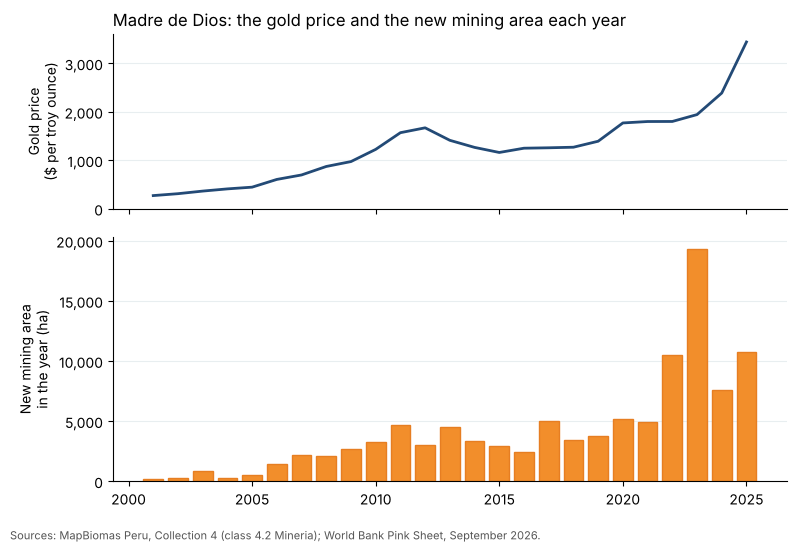

In [5]:
plot = mdd[mdd["year"] >= 2001]
fig, (top, bottom) = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True, gridspec_kw={"height_ratios": [1, 1.4]})

top.plot(plot["year"], plot["gold"], color="#234A76", linewidth=2)
top.set_ylabel("Gold price\n($ per troy ounce)")
top.set_ylim(0, None)
top.set_title("Madre de Dios: the gold price and the new mining area each year", loc="left")

bottom.bar(plot["year"], plot["addition_ha"], color="#F28E2B", edgecolor="#E67E22", width=0.8)
bottom.set_ylabel("New mining area\nin the year (ha)")

for ax in (top, bottom):                      # two panels, one x-axis: never two y-axes on one panel
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, color="#E8EEF0"); ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:,.0f}"))

fig.text(0.01, 0.01, "Sources: MapBiomas Peru, Collection 4 (class 4.2 Mineria); World Bank Pink Sheet, September 2026.",
         fontsize=8, color="#555555")
fig.tight_layout(rect=(0, 0.04, 1, 1))
Path("output").mkdir(exist_ok=True)
fig.savefig("output/starter_figure.png", dpi=200)
print("Saved output/starter_figure.png")

## What next

- Open your question card. Do the "Describe" step for your own units and years.
- Download the table your card asks you to add. Add one row for it to `DOWNLOAD_LOG.csv`
  and write a `check(...)` line for it like the ones above.
- Keep everything in one script or notebook that runs from top to bottom. That file,
  the log and your raw downloads are your replication folder.